# ANALISIS DE PRODUCCION DE FABRICA

Proyecto de practica en analisis de datos sobre datos de produccion de empresas

Autor: Angel Abdel Robles Carreon

# Import de librerias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Lectura de archivo de base de datos

In [3]:
df= pd.read_csv ("manufacturing_quality_decisions_10000.csv")


# Analisis del contenido del dataset


In [4]:
print(df.columns)
print(df.head())
print(df.info())



Index(['event_id', 'event_ts', 'plant', 'line', 'shift', 'machine_id',
       'operator_id', 'machine_age_yrs', 'material_grade', 'temp_c',
       'humidity_pct', 'process_speed_units_hr', 'inspection_method',
       'defect_type', 'defect_severity_0to3', 'decision_rework',
       'rework_time_min', 'final_pass', 'scrap', 'total_cycle_time_min',
       'energy_kwh', 'cost_usd', 'warranty_claim_90d'],
      dtype='object')
  event_id             event_ts    plant    line  shift machine_id  \
0  M200000  2025-08-27 17:15:31  plant_1  line_A    day      MC104   
1  M200001  2025-11-09 16:28:50  plant_1  line_A  swing      MC158   
2  M200002  2025-12-20 06:18:01  plant_1  line_D  night      MC144   
3  M200003  2025-12-06 12:38:46  plant_2  line_B  night      MC108   
4  M200004  2025-07-31 07:28:14  plant_1  line_C    day      MC113   

  operator_id  machine_age_yrs material_grade  temp_c  ...  defect_type  \
0      OP1009             1.55        grade_B     5.9  ...         none   
1  

# Definimos las problematicas a analizar de la empresa con el dataset

- ¿Qué línea genera más scrap?
- ¿Qué turno genera más scrap?
- ¿Qué línea tiene el mayor tiempo promedio de ciclo?
- ¿Qué máquinas presentan los mayores tiempos promedio de ciclo?
- Linea con el mayor tiempo promedio de operacion



# LIMPIEZA Y TRANSFORMACION DE DATOS


In [5]:
df.isnull().sum()

df.duplicated().sum()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_id                10000 non-null  object 
 1   event_ts                10000 non-null  object 
 2   plant                   10000 non-null  object 
 3   line                    10000 non-null  object 
 4   shift                   10000 non-null  object 
 5   machine_id              10000 non-null  object 
 6   operator_id             10000 non-null  object 
 7   machine_age_yrs         10000 non-null  float64
 8   material_grade          10000 non-null  object 
 9   temp_c                  10000 non-null  float64
 10  humidity_pct            10000 non-null  float64
 11  process_speed_units_hr  10000 non-null  float64
 12  inspection_method       10000 non-null  object 
 13  defect_type             10000 non-null  object 
 14  defect_severity_0to3    10000 non-null 

# Analisis basado en las cuestiones de la empresa


line
line_D    73
line_C    65
line_B    58
line_A    52
Name: scrap, dtype: int64


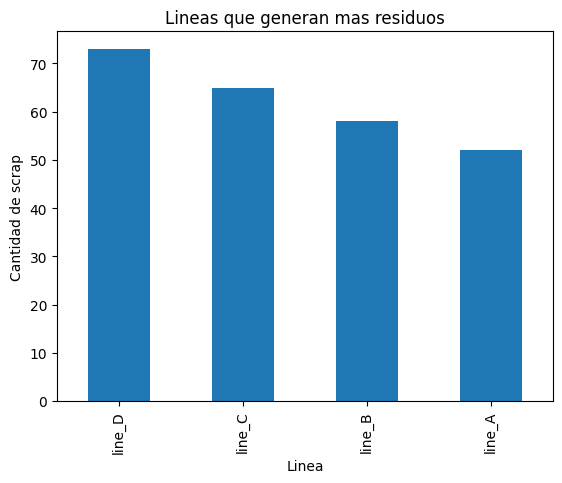

In [ ]:
# ¿Qué línea genera más scrap?


Lineaconmasresiduos = df.groupby("line")["scrap"].sum().sort_values(ascending=False)
print(Lineaconmasresiduos)

Lineaconmasresiduos.plot(kind="bar")
plt.title("Lineas que generan mas residuos")
plt.xlabel("Linea")
plt.ylabel("Cantidad de scrap")
plt.show()


shift
day      111
swing     82
night     55
Name: scrap, dtype: int64


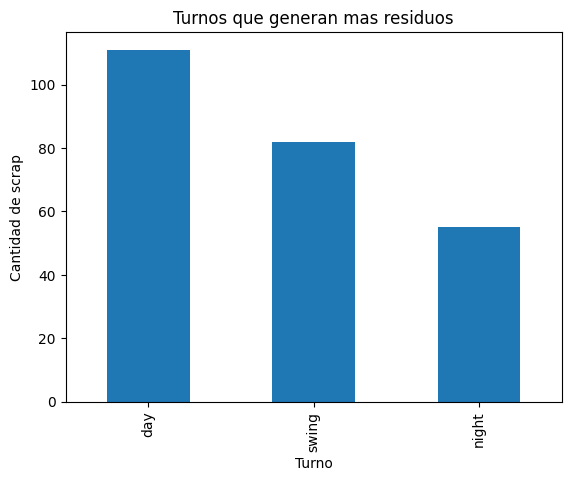

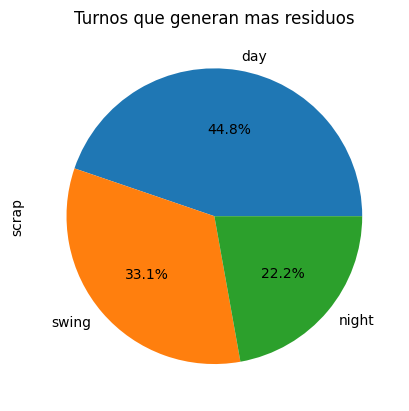

In [ ]:
# ¿Qué turno genera más scrap?

Turnoconmasresiduos = df.groupby("shift")["scrap"].sum().sort_values(ascending=False)
print(Turnoconmasresiduos)

Turnoconmasresiduos.plot(kind="bar")
plt.title("Turnos que generan mas residuos")
plt.xlabel("Turno")
plt.ylabel("Cantidad de scrap")
plt.show()

Turnoconmasresiduos.plot(kind="pie", autopct="%1.1f%%")
plt.title("Turnos que generan mas residuos")
plt.show()

line
line_D    36.607805
line_B    34.055877
line_A    33.738477
line_C    33.585322
Name: total_cycle_time_min, dtype: float64


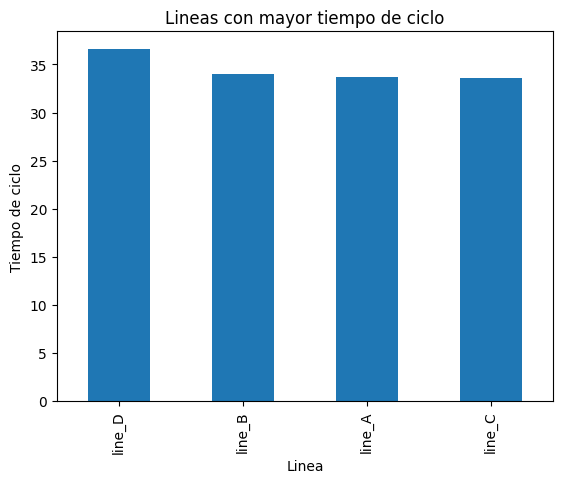

In [ ]:
#¿Qué línea tiene el mayor tiempo promedio de ciclo?

Lineaconmastiempo = df.groupby("line")["total_cycle_time_min"].mean().sort_values(ascending=False)
print(Lineaconmastiempo)

Lineaconmastiempo.plot(kind="bar")
plt.title("Lineas con mayor tiempo de ciclo")
plt.xlabel("Linea")
plt.ylabel("Tiempo de ciclo")
plt.show()

machine_id
MC126    37.511170
MC150    37.464835
MC142    36.843889
MC113    36.332886
MC137    36.179720
MC107    35.901596
MC149    35.890000
MC119    35.789349
MC133    35.708284
MC144    35.651685
Name: total_cycle_time_min, dtype: float64


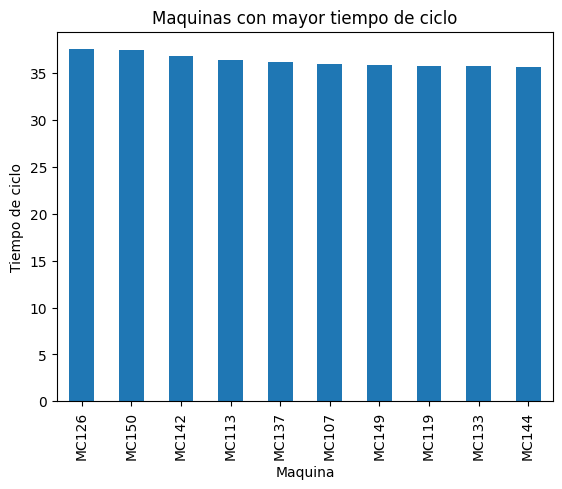

In [ ]:
# ¿Qué máquinas presentan los mayores tiempos promedio de ciclo?
maquinasconmayortiempodeciclo = df.groupby("machine_id")["total_cycle_time_min"].mean().sort_values(ascending= False).head(10)
print(maquinasconmayortiempodeciclo)

maquinasconmayortiempodeciclo.plot(kind="bar")
plt.title("Maquinas con mayor tiempo de ciclo")
plt.xlabel("Maquina")
plt.ylabel("Tiempo de ciclo")
plt.show()


line
line_D    36.607805
line_B    34.055877
line_A    33.738477
line_C    33.585322
Name: total_cycle_time_min, dtype: float64


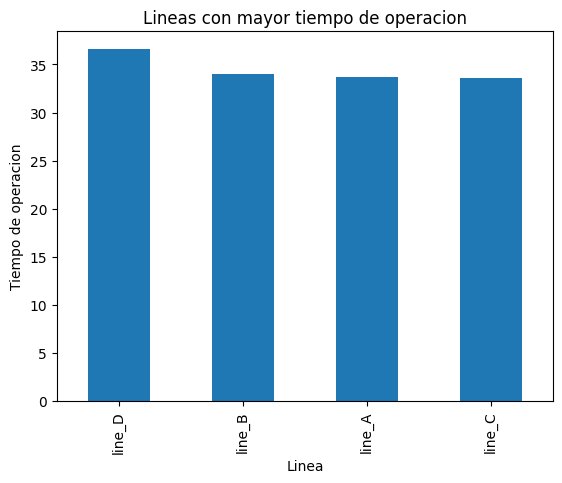

In [6]:
#Linea con el mayor tiempo promedio de operacion
lineaconmayortiempodeoperacion = df.groupby("line")["total_cycle_time_min"].mean().sort_values(ascending= False)
print(lineaconmayortiempodeoperacion)

lineaconmayortiempodeoperacion.plot(kind="bar")
plt.title("Lineas con mayor tiempo de operacion")
plt.xlabel("Linea")
plt.ylabel("Tiempo de operacion")
plt.show()

# Conclusiones.

A partir del análisis exploratorio realizado sobre 10,000 registros
de producción, se identificaron los siguientes hallazgos clave:

- **Line_D es la línea más crítica:** concentra el mayor volumen de
  scrap (73 unidades) y el mayor tiempo promedio de ciclo (36.6 min),
  lo que la convierte en la línea prioritaria para intervención y mejora.

- **El turno day genera más scrap:** con 111 unidades representa el
  45% del scrap total, duplicando al turno nocturno (55 unidades).
  Esto sugiere revisar condiciones operativas, carga de trabajo
  y supervisión durante ese turno.

- **Las máquinas MC126 y MC150 son las más lentas:** con tiempos
  promedio de ciclo de 37.5 y 37.4 minutos respectivamente,
  superando a la mayoría de las máquinas del parque industrial.

- **La antigüedad no es el factor determinante del scrap:**
  los resultados muestran que máquinas con edades muy distintas
  (desde 1 año hasta 9 años) generan niveles similares de scrap,
  lo que indica que otros factores como el turno o la línea
  tienen mayor influencia.